In [1]:
import tensorflow as tf
import os
import cv2
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns


I0000 00:00:1778885869.441040   14630 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778885869.499208   14630 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778885870.798421   14630 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### Fuentes
- https://www.geeksforgeeks.org/machine-learning/activation-functions-neural-networks/

In [2]:
train = pd.read_csv("./data/train.csv")
test = pd.read_csv("./data/test.csv")

In [3]:
train

,product_type,air_temp [K],process_temp [K],torque [Nm],tool_wear [min],target
0,0.0,-1.588786,-1.334958,0.509232,-1.090530,0
1,1.0,-1.485697,-1.108159,0.692203,0.307820,0
2,0.0,-1.207357,-1.478597,1.317821,-1.518596,1
3,0.0,0.452378,0.675995,0.240406,1.221028,1
4,0.0,-1.073341,-0.654560,-0.131164,0.578929,0
...,...,...,...,...,...,...
11611,0.0,0.864735,0.751594,0.849135,1.178222,1
11612,0.0,0.472996,0.328236,-0.074866,1.206760,0
11613,0.0,0.163729,1.386632,-0.539329,0.550391,0
11614,0.0,0.730719,0.456755,1.384676,-1.033455,1


In [4]:
test

,product_type,air_temp [K],process_temp [K],torque [Nm],tool_wear [min],target
0,0.0,-0.970252,-0.276562,0.051806,0.265013,0
1,0.0,-0.599131,-0.669680,-0.219835,1.178222,1
2,2.0,1.658521,2.067030,0.340336,-1.761167,0
3,1.0,0.936897,-0.049763,-0.504143,-1.347370,0
4,0.0,1.658521,1.613431,0.086993,-0.391355,0
...,...,...,...,...,...,...
2900,0.0,-0.325945,0.063637,1.305858,-0.519775,1
2901,2.0,-0.609440,-1.032559,0.030694,0.935651,0
2902,0.0,-0.836236,-0.397521,-1.215616,0.479047,1
2903,0.0,-0.037295,0.184596,-2.435185,0.093787,1


In [5]:
X_train = train.drop('target', axis=1)
y_train = train['target']

X_test = test.drop(columns=['target'])
y_test = test['target']

In [6]:
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_data=(X_train, y_train),
                    callbacks=[early_stop])

Epoch 1/50


/home/marcos-debona/Escritorio/Facultad/TP IA/TP1-IA-2026/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1778885872.151046   14630 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7775 - loss: 0.4700 - val_accuracy: 0.8696 - val_loss: 0.3211
Epoch 2/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8613 - loss: 0.3298 - val_accuracy: 0.8979 - val_loss: 0.2595
Epoch 3/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8758 - loss: 0.2926 - val_accuracy: 0.9072 - val_loss: 0.2363
Epoch 4/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8889 - loss: 0.2711 - val_accuracy: 0.9127 - val_loss: 0.2238
Epoch 5/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8973 - loss: 0.2589 - val_accuracy: 0.9154 - val_loss: 0.2160
Epoch 6/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9015 - loss: 0.2494 - val_accuracy: 0.9245 - val_loss: 0.2081
Epoch 7/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9038 - loss: 0.2439 - val_accuracy: 0.9234 - val_loss: 0.2040
Epoch 8/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9080 - loss: 0.2326 - val_accuracy: 0.9291 - val_

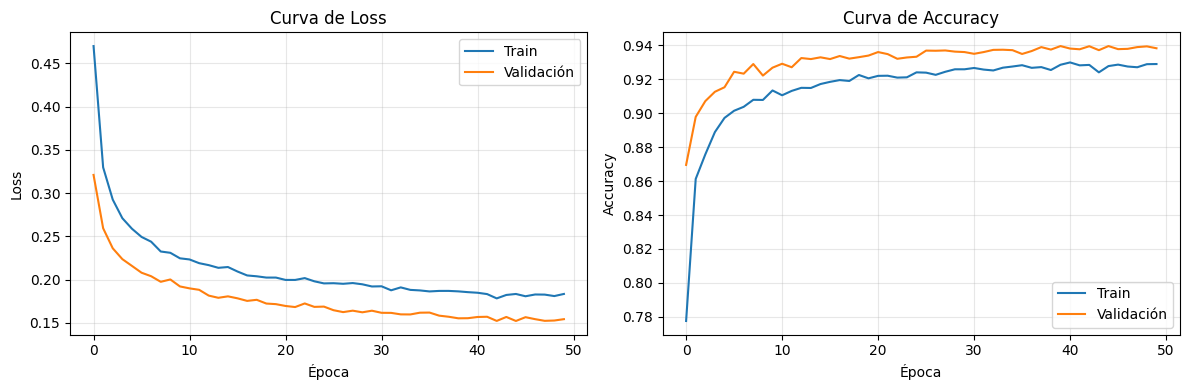

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Curva de Loss
ax1.plot(history.history['loss'], label='Train')
ax1.plot(history.history['val_loss'], label='Validación')
ax1.set_title('Curva de Loss')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Curva de Accuracy
ax2.plot(history.history['accuracy'], label='Train')
ax2.plot(history.history['val_accuracy'], label='Validación')
ax2.set_title('Curva de Accuracy')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Prueba para hacer busqueda de mejores hiperparametros (revisar y  mejorar)

In [8]:
import keras_tuner as kt

def build_model(hp):
    model = keras.Sequential()
    
    model.add(keras.layers.Dense(
        units=hp.Choice('units_1', [32, 64, 128]),
        activation='relu',
        input_shape=(X_train.shape[1],)
    ))
    
    model.add(keras.layers.Dense(
        units=hp.Choice('units_2', [16, 32, 64]),
        activation='relu'
    ))
    
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('lr', [1e-2, 1e-3, 1e-4])
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,           # cuántas combinaciones probar
    executions_per_trial=1,
    directory='tuner_results',
    project_name='tp_ia'
)

tuner.search(X_train, y_train,
             epochs=50,
             batch_size=32,
             validation_split=0.2,
             verbose=1)

# Ver los mejores hiperparámetros
tuner.results_summary()
best_hp = tuner.get_best_hyperparameters()[0]
print(f"\nMejor config: units_1={best_hp.get('units_1')}, units_2={best_hp.get('units_2')}, lr={best_hp.get('lr')}")


Reloading Tuner from tuner_results/tp_ia/tuner0.json

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
128               |64                |units_1
16                |32                |units_2
0.001             |0.001             |lr



Traceback (most recent call last):
  File "/home/marcos-debona/Escritorio/Facultad/TP IA/TP1-IA-2026/venv/lib/python3.12/site-packages/keras_tuner/src/engine/base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "/home/marcos-debona/Escritorio/Facultad/TP IA/TP1-IA-2026/venv/lib/python3.12/site-packages/keras_tuner/src/engine/base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/marcos-debona/Escritorio/Facultad/TP IA/TP1-IA-2026/venv/lib/python3.12/site-packages/keras_tuner/src/engine/tuner.py", line 309, in run_trial
    self._configure_tensorboard_dir(callbacks, trial, execution)
  File "/home/marcos-debona/Escritorio/Facultad/TP IA/TP1-IA-2026/venv/lib/python3.12/site-packages/keras_tuner/src/engine/tuner.py", line 421, in _configure_tensorboard_dir
    from tensorboard.plugins.hpa

RuntimeError: Number of consecutive failures exceeded the limit of 3.
Traceback (most recent call last):
  File "/home/marcos-debona/Escritorio/Facultad/TP IA/TP1-IA-2026/venv/lib/python3.12/site-packages/keras_tuner/src/engine/base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "/home/marcos-debona/Escritorio/Facultad/TP IA/TP1-IA-2026/venv/lib/python3.12/site-packages/keras_tuner/src/engine/base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/marcos-debona/Escritorio/Facultad/TP IA/TP1-IA-2026/venv/lib/python3.12/site-packages/keras_tuner/src/engine/tuner.py", line 309, in run_trial
    self._configure_tensorboard_dir(callbacks, trial, execution)
  File "/home/marcos-debona/Escritorio/Facultad/TP IA/TP1-IA-2026/venv/lib/python3.12/site-packages/keras_tuner/src/engine/tuner.py", li